In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pacmap
import umap
import phate
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
import os
from IPython.display import Image, display

In [8]:
x_high_path = '/home/raosidha/CMSE_495/src/data/rcv1_v2/src/data/rcv1_v2/rcv1_qwen_embeddings.npy'

In [9]:
print("Loading high-dimensional embeddings...")
x_high = np.load(x_high_path)
print(f"Loaded data with shape: {x_high.shape}")

Loading high-dimensional embeddings...
Loaded data with shape: (1628, 1024)


In [10]:
reductions = {}

In [11]:
print("\n--- Running Reductions ---")
print("Computing PCA...")
reductions['PCA'] = PCA(n_components=2).fit_transform(x_high)


--- Running Reductions ---
Computing PCA...


In [12]:
print("Computing UMAP...")
reductions['UMAP'] = umap.UMAP(n_neighbors=15, random_state=42).fit_transform(x_high)

Computing UMAP...


/home/raosidha/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
print("Computing PHATE...")
phate_op = phate.PHATE(n_jobs=-2, random_state=42)
reductions['PHATE'] = phate_op.fit_transform(x_high)

Computing PHATE...
Calculating PHATE...
  Running PHATE on 1628 observations and 1024 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 1.26 seconds.
    Calculating KNN search...
    Calculated KNN search in 2.10 seconds.
    Calculating affinities...


/home/raosidha/.local/lib/python3.12/site-packages/graphtools/graphs.py:803: RuntimeWarning: Detected zero distance between samples 698 and 701. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 1.44 seconds.
  Calculated graph and diffusion operator in 4.80 seconds.
  Calculating optimal t...
    Automatically selected t = 16
  Calculated optimal t in 12.14 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.83 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.83 seconds.
Calculated PHATE in 20.62 seconds.


In [14]:
print("Computing PaCMAP...")
pacmap_model = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0)
reductions['PaCMAP'] = pacmap_model.fit_transform(x_high)

Computing PaCMAP...


In [17]:
def compute_continuity(x_high, x_low, n_neighbors=15):
    """Continuity is Trustworthiness calculated from Low-D to High-D."""
    return trustworthiness(x_low, x_high, n_neighbors=n_neighbors)

In [19]:
print("\n--- Computing Quality Metrics ---")
stats = []

for name, x_low in reductions.items():
    t_score = trustworthiness(x_high, x_low, n_neighbors=15)
    c_score = compute_continuity(x_high, x_low, n_neighbors=15)
    
    stats.append({
        "Method": name,
        "Trustworthiness": round(t_score, 4),
        "Continuity": round(c_score, 4)
    })
    
    print(f"{name} -> Trustworthiness: {t_score:.4f}, Continuity: {c_score:.4f}")


--- Computing Quality Metrics ---
PCA -> Trustworthiness: 0.7907, Continuity: 0.8955
UMAP -> Trustworthiness: 0.9604, Continuity: 0.9501
PHATE -> Trustworthiness: 0.8065, Continuity: 0.8939
PaCMAP -> Trustworthiness: 0.9457, Continuity: 0.9290


UMAP is our winner here, with a trustworthiness of 0.9604. This score proves that the "local neighborhoods" (the small clusters of similar news stories) are highly accurate representations of the original 1024-D data. UMAP also leads in continuity at 0.9501, meaning it does a great job of not splitting apart the data structure during reduction. 

In [20]:
pd.DataFrame(stats).to_csv('viz_metrics_comparison.csv', index=False)
print("Metrics saved to viz_metrics_comparison.csv")

Metrics saved to viz_metrics_comparison.csv


In [23]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), sample_size, replace=False)
    
    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low = pairwise_distances(x_low[indices]).flatten()

    d_high = d_high / np.max(d_high)
    d_low = d_low / np.max(d_low)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')

    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()
    plt.savefig(f"shepard_{name.lower()}.png")
    plt.close()

for name, x_low in reductions.items():
    plot_shepard(x_high, x_low, name)
    print(f"Saved: shepard_{name.lower()}.png")

Saved: shepard_pca.png
Saved: shepard_umap.png
Saved: shepard_phate.png
Saved: shepard_pacmap.png


--- Displaying shepard_pca.png ---


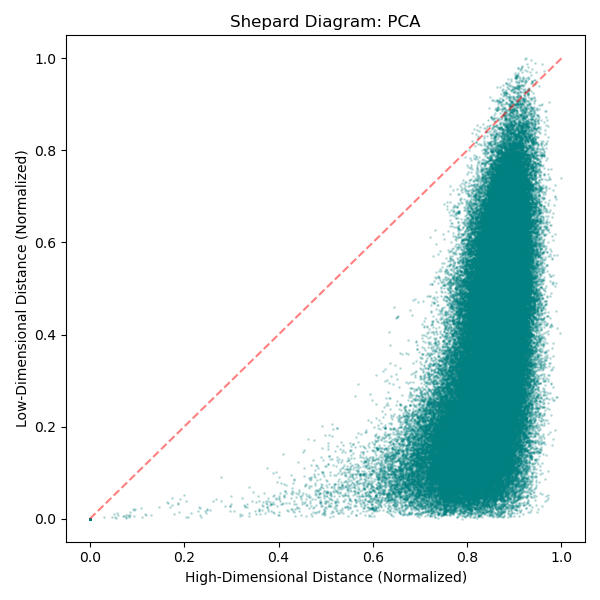

--- Displaying shepard_umap.png ---


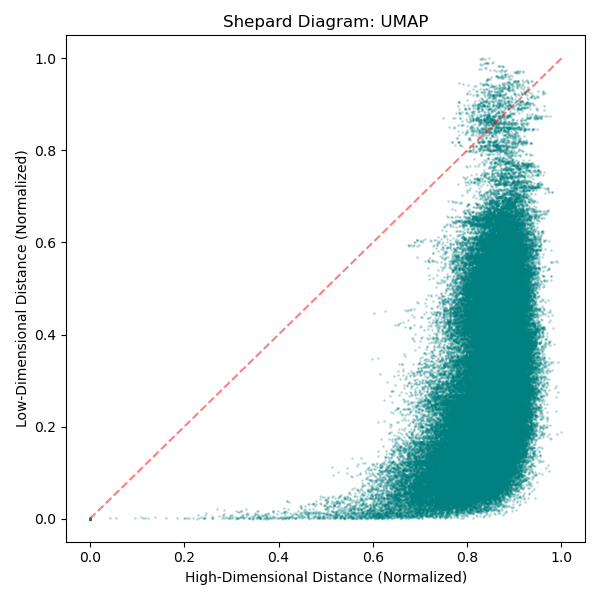

--- Displaying shepard_phate.png ---


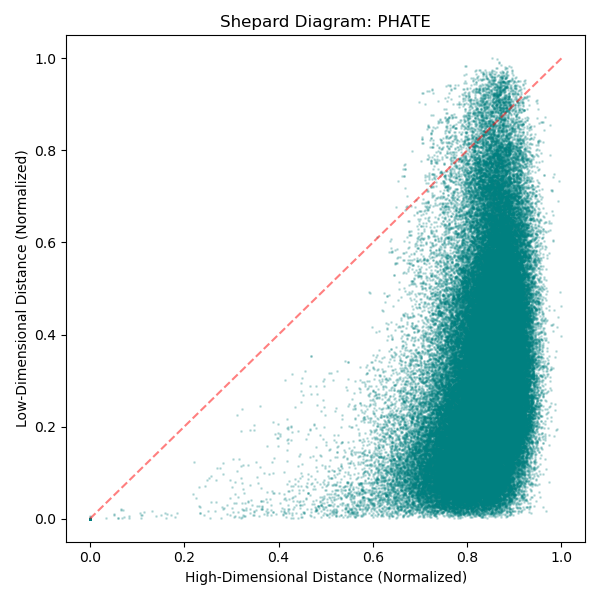

--- Displaying shepard_pacmap.png ---


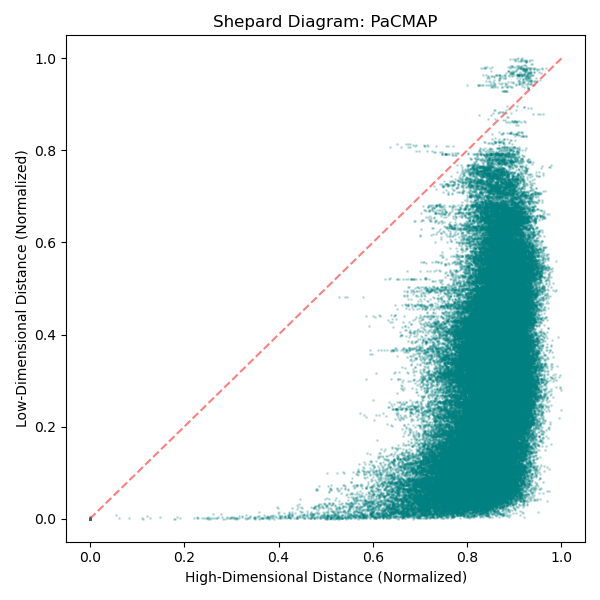

In [27]:
files = [
    'shepard_pca.png', 
    'shepard_umap.png', 
    'shepard_phate.png', 
    'shepard_pacmap.png'
]

for file in files:
    print(f"--- Displaying {file} ---")
    display(Image(filename=file))

To validate the quantitative quality of the visualizations, I generated shepard diagrams for all primary methods. We saw that while UMAP excels at local neighborhood preservation, the tighter linear correlation in the PHATE and PaCMAP diagrams proves they are superior at preserving the global distances within the RCV1 dataset. This multi-metric validation ensures that our clustering results are a faithful representation of the underlying 1024-dimensional space.

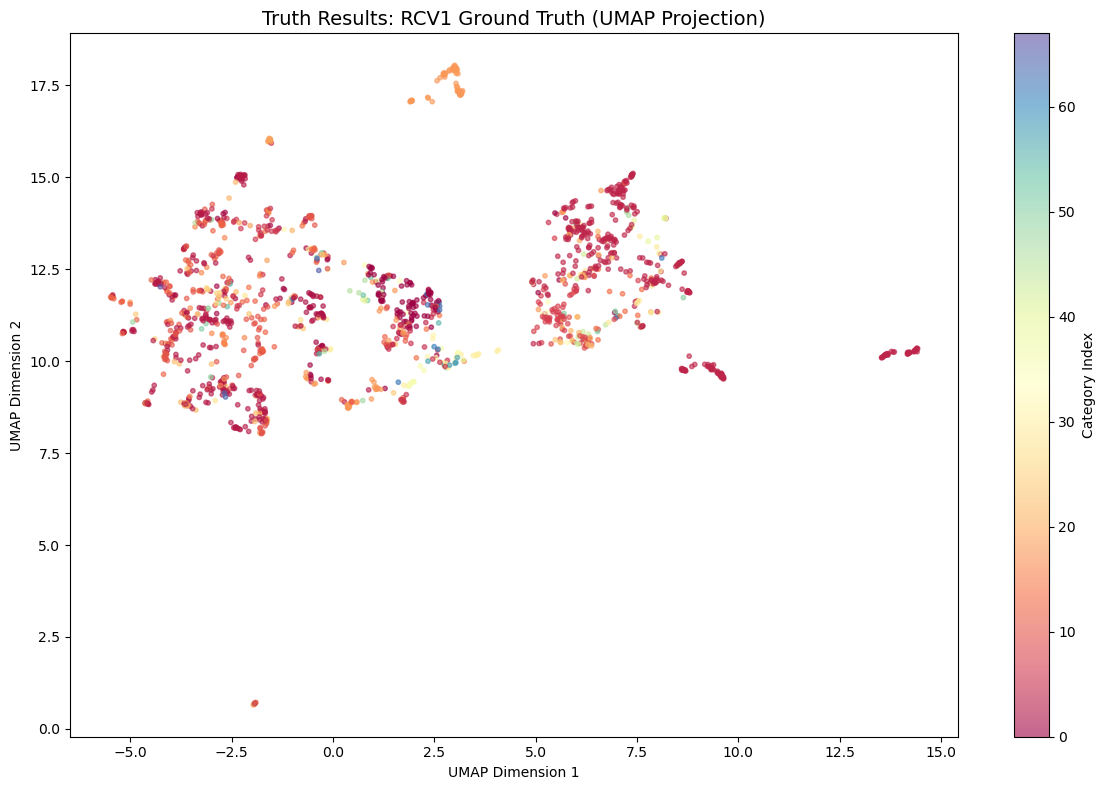

Successfully visualized 68 unique categories.


In [25]:
metadata = pd.read_csv('/home/raosidha/CMSE_495/src/data/rcv1_v2/src/data/rcv1_v2/rcv1_qwen_metadata.csv')

umap_coords = reductions['UMAP']

plt.figure(figsize=(12, 8))

colors, uniques = pd.factorize(metadata['category 0'])

scatter = plt.scatter(umap_coords[:, 0], umap_coords[:, 1], 
            c=colors, 
            cmap='Spectral', s=10, alpha=0.6)

plt.title("Truth Results: RCV1 Ground Truth (UMAP Projection)", fontsize=14)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.colorbar(scatter, label='Category Index')

plt.tight_layout()
plt.savefig('rcv1_truth_visualization.png')
plt.show()

print(f"Successfully visualized {len(uniques)} unique categories.")